Stage 1: Extract Landmark bằng mediapipe, tạo data type là json để lưu tạm thời dữ liệu trên RAM
Stage 2: Tính toán thành face feature, CSV trên RAM
Stage 3: Nén face feature, output CSV

Dữ liệu cuối cùng là tabular bên trong CSV nên ta dùng Decision Tree, Random Forest và XGboost

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


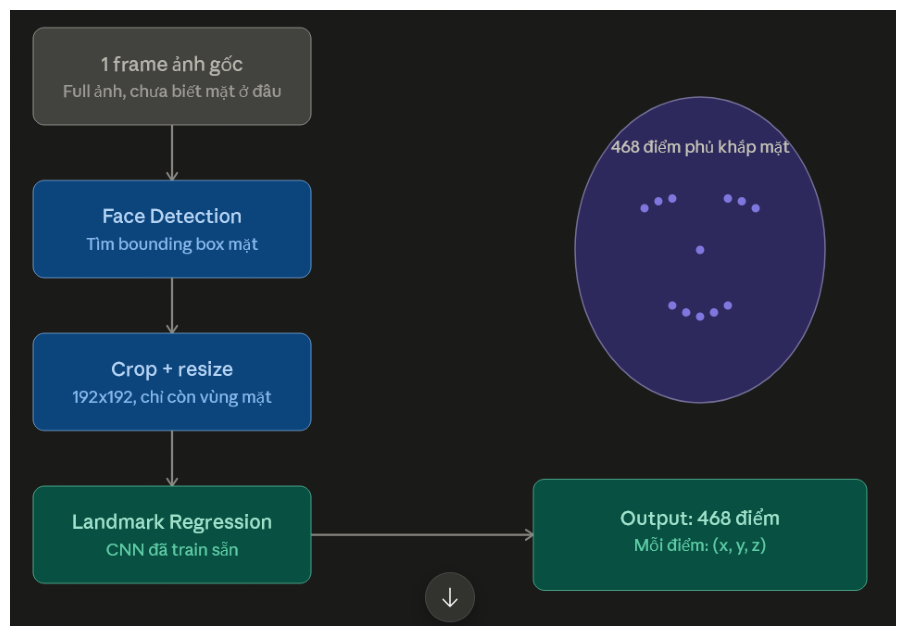

In [2]:

img = mpimg.imread(r"C:\Users\KIET PC\Desktop\Focus_Guard\Screenshot 2026-08-08 115540.png")
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
"""
extract_stage1_only.py
CHI giu Stage 1 -- extract landmark tho tu CAC VIDEO trong 1 folder input,
luu ra folder output (khong tinh EAR/MAR, khong ve, khong webcam).
"""

import json
from pathlib import Path

import cv2
import mediapipe as mp

mp_face_mesh = mp.solutions.face_mesh

# ---------------------------------------------------------------------
# INPUT / OUTPUT -- SUA 2 DONG NAY CHO DUNG MAY BAN
# ---------------------------------------------------------------------
INPUT_DIR = Path(r"C:\Users\KIET PC\Desktop\Focus_Guard\DAiSEE\DataSet\Train")  # folder chua video .avi
OUTPUT_DIR = Path(r"C:\Users\KIET PC\Desktop\Focus_Guard\stage1_landmarks_output")

SAMPLE_FPS = 3          # chi lay 3 frame/giay, khong lay het
MAX_FRAMES_PER_VIDEO = 50


def extract_landmarks_from_video(video_path: Path, output_subdir: Path):
    """Chay Stage 1 cho 1 video, luu moi frame detect duoc ra 1 file JSON."""
    output_subdir.mkdir(parents=True, exist_ok=True)

    cap = cv2.VideoCapture(str(video_path))
    video_fps = cap.get(cv2.CAP_PROP_FPS) or 30
    frame_interval = max(1, int(video_fps / SAMPLE_FPS))

    frame_idx = 0
    saved_count = 0

    with mp_face_mesh.FaceMesh(
        static_image_mode=False,
        max_num_faces=1,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5,
    ) as face_mesh:

        while cap.isOpened() and saved_count < MAX_FRAMES_PER_VIDEO:
            success, image = cap.read()
            if not success:
                break

            if frame_idx % frame_interval == 0:
                image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                results = face_mesh.process(image_rgb)

                if results.multi_face_landmarks:
                    face_landmarks = results.multi_face_landmarks[0]

                    landmarks_data = {
                        "video": video_path.name,
                        "frame_index": frame_idx,
                        "landmarks": [
                            {"index": idx, "x": lm.x, "y": lm.y, "z": lm.z}
                            for idx, lm in enumerate(face_landmarks.landmark)
                        ],
                    }

                    output_path = output_subdir / f"frame_{frame_idx:05d}.json"
                    with open(output_path, "w", encoding="utf-8") as f:
                        json.dump(landmarks_data, f)

                    saved_count += 1

            frame_idx += 1

    cap.release()
    return saved_count


def main():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    video_files = list(INPUT_DIR.rglob("*.avi")) + list(INPUT_DIR.rglob("*.mp4"))
    print(f"Tim thay {len(video_files)} video trong {INPUT_DIR}")

    for video_path in video_files:
        video_output_subdir = OUTPUT_DIR / video_path.stem
        saved = extract_landmarks_from_video(video_path, video_output_subdir)
        print(f"  {video_path.name}: luu {saved} frame -> {video_output_subdir}")

    print(f"\nHoan tat. Ket qua nam trong: {OUTPUT_DIR.resolve()}")


if __name__ == "__main__":
    main()